In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
data = pd.read_excel('data/Cleaned_Shark_Tank_India.xlsx')
display(data.head())
display(data.columns)


,Season Number,Industry,Pitchers Average Age,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,EBITDA,Has Patents,Bootstrapped,...,Valuation Requested,Received Offer,Accepted Offer,Number of Sharks in Deal,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Company Age
0,1,Food And Beverage,1,95.0,8.000000,51.0,20.0,6.0,0,0,...,1000.0,1,1,3,75.0,16.00,0,0.0,469.0,5
1,1,Vehicles/Electrical Vehicles,0,4.0,0.400000,95.0,20.0,15.5,0,0,...,267.0,1,1,2,40.0,50.00,0,0.0,80.0,4
2,1,Beauty/Fashion,0,0.0,0.000000,60.0,16.0,13.5,0,0,...,250.0,1,1,2,25.0,30.00,0,0.0,83.0,0
3,1,Food And Beverage,1,700.0,58.333333,48.0,20.0,6.0,0,0,...,7000.0,1,1,1,70.0,2.75,0,0.0,2545.0,2
4,1,Children/Education,1,30.0,2.500000,54.0,20.0,15.0,0,0,...,1000.0,0,0,0,0.0,0.00,0,0.0,0.0,6


Index(['Season Number', 'Industry', 'Pitchers Average Age', 'Yearly Revenue',
       'Monthly Sales', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Valuation Requested', 'Received Offer',
       'Accepted Offer', 'Number of Sharks in Deal', 'Total Deal Amount',
       'Total Deal Equity', 'Total Deal Debt', 'Debt Interest',
       'Deal Valuation', 'Company Age'],
      dtype='object')

In [3]:
columns_to_drop = ['Received Offer' , 'Accepted Offer', 'Number of Sharks in Deal',
                    'Total Deal Amount', 'Total Deal Equity', 'Total Deal Debt',
                      'Debt Interest', 'Accepted Offer', 'Received Offer' ,'Season Number',]

df = data.drop(columns=columns_to_drop)
df = df[df['Deal Valuation'] > 0]
    
# Define your target variable
target = 'Deal Valuation'

display(df.head())
display(df.shape)
display(df.columns)

,Industry,Pitchers Average Age,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,EBITDA,Has Patents,Bootstrapped,SKUs,Original Ask Amount,Original Offered Equity,Valuation Requested,Deal Valuation,Company Age
0,Food And Beverage,1,95.0,8.000000,51.0,20.0,6.0,0,0,20,50.0,5.0,1000.0,469.0,5
1,Vehicles/Electrical Vehicles,0,4.0,0.400000,95.0,20.0,15.5,0,0,65,40.0,15.0,267.0,80.0,4
2,Beauty/Fashion,0,0.0,0.000000,60.0,16.0,13.5,0,0,65,25.0,10.0,250.0,83.0,0
3,Food And Beverage,1,700.0,58.333333,48.0,20.0,6.0,0,0,20,70.0,1.0,7000.0,2545.0,2
7,Beauty/Fashion,0,100.0,8.333333,60.0,16.0,13.5,0,0,2,75.0,4.0,1875.0,1250.0,2


(430, 15)

Index(['Industry', 'Pitchers Average Age', 'Yearly Revenue', 'Monthly Sales',
       'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents', 'Bootstrapped',
       'SKUs', 'Original Ask Amount', 'Original Offered Equity',
       'Valuation Requested', 'Deal Valuation', 'Company Age'],
      dtype='object')

# EDA

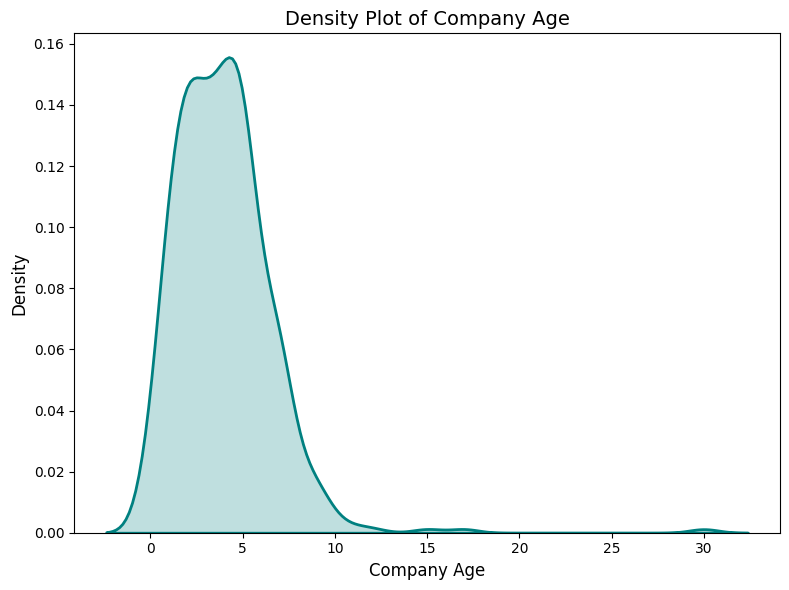

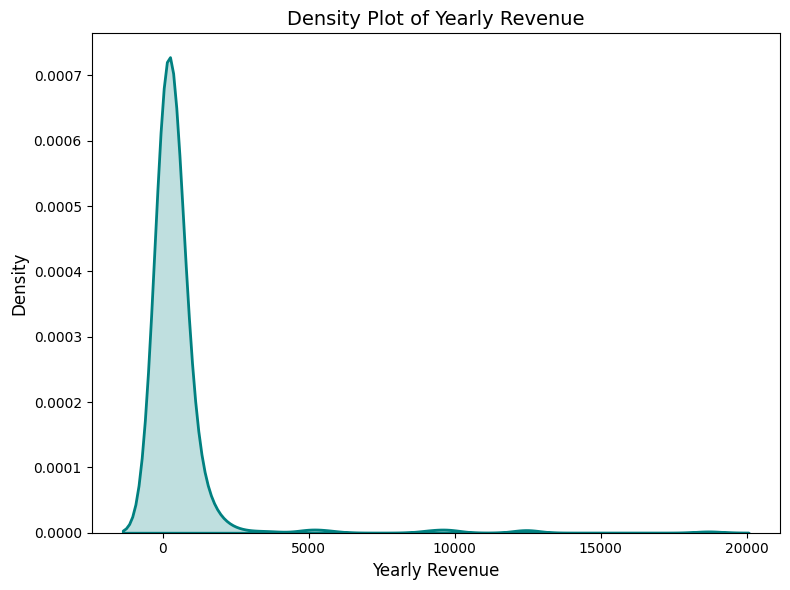

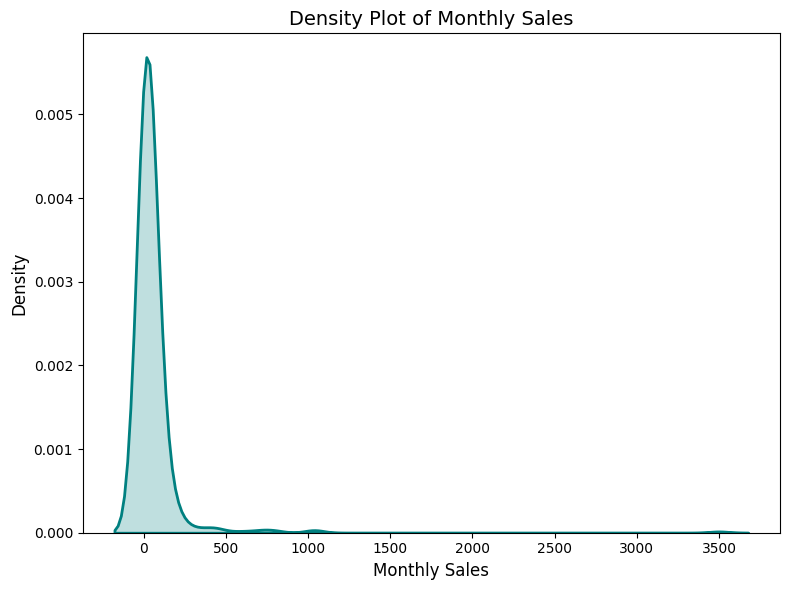

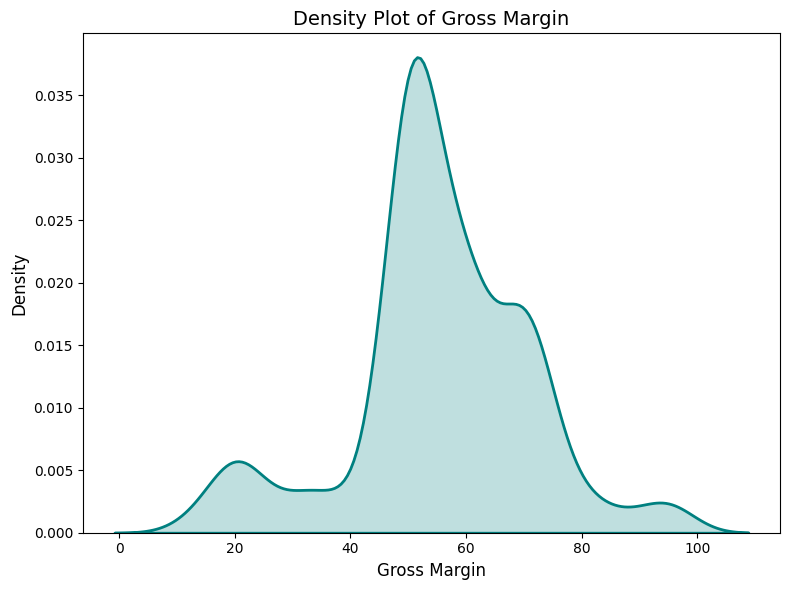

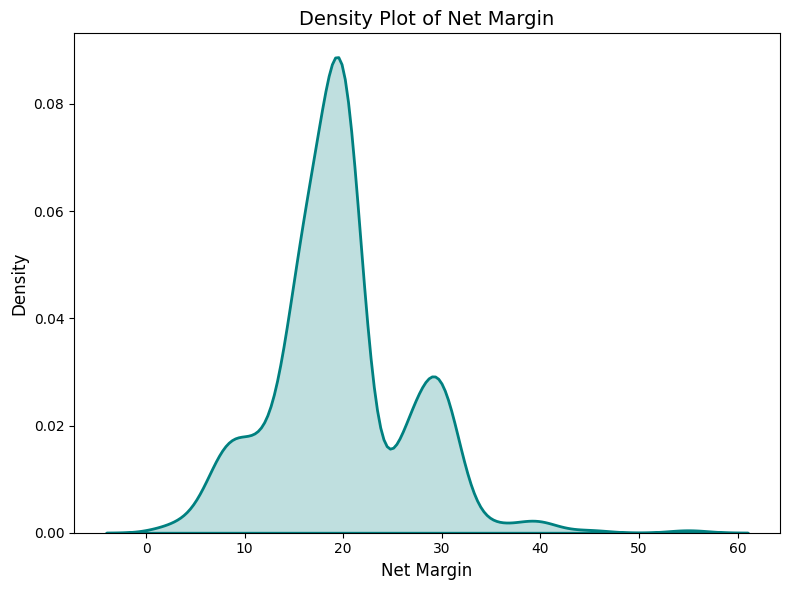

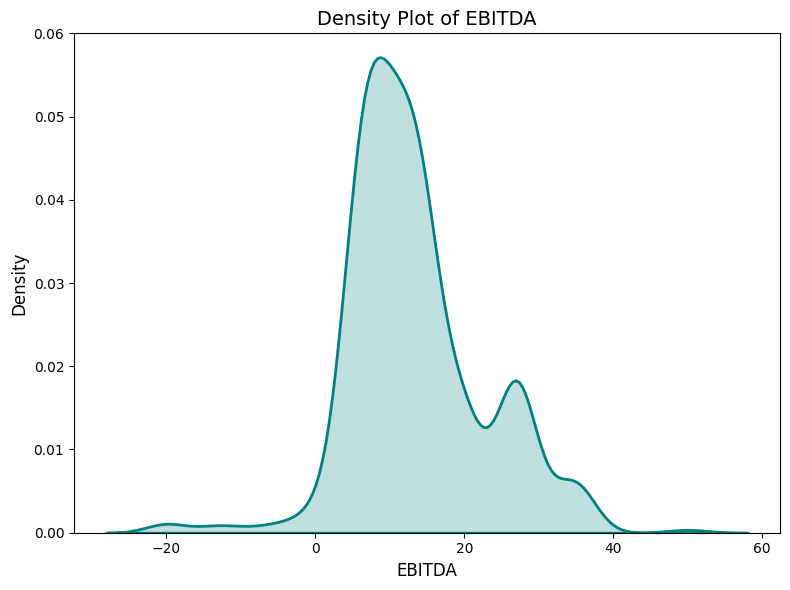

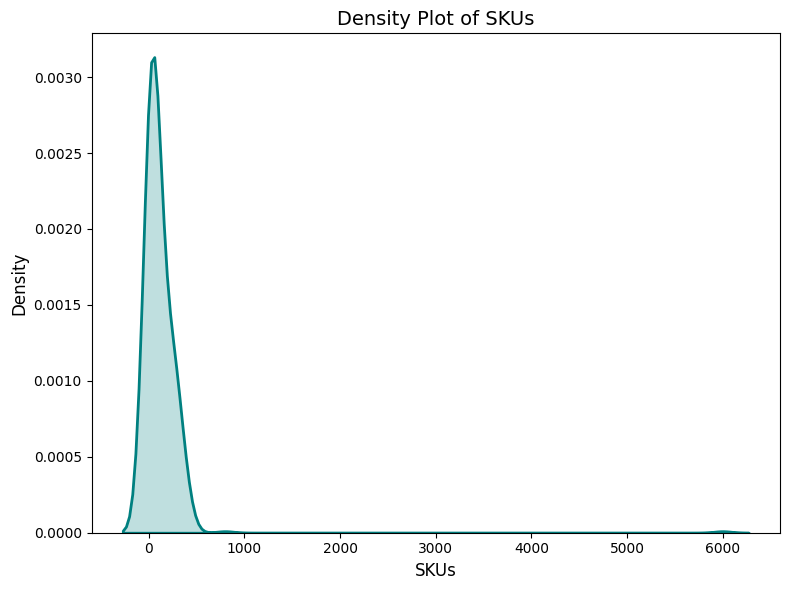

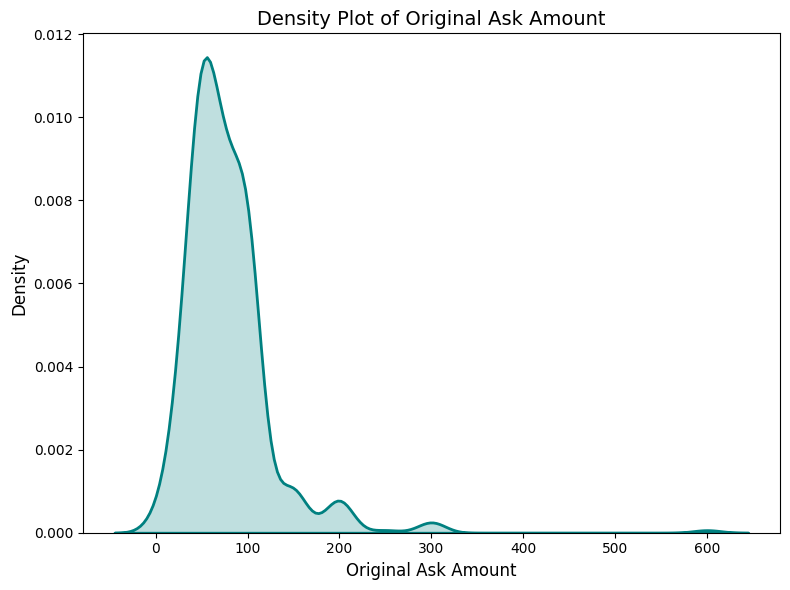

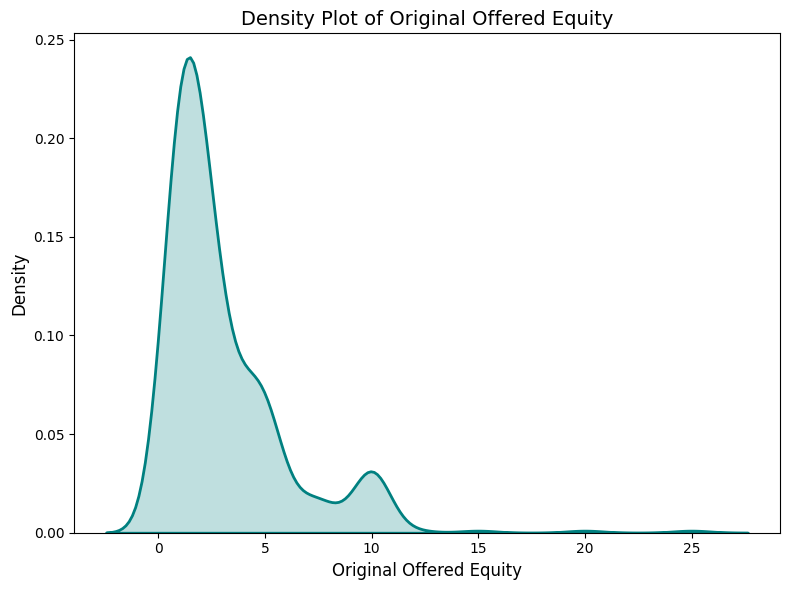

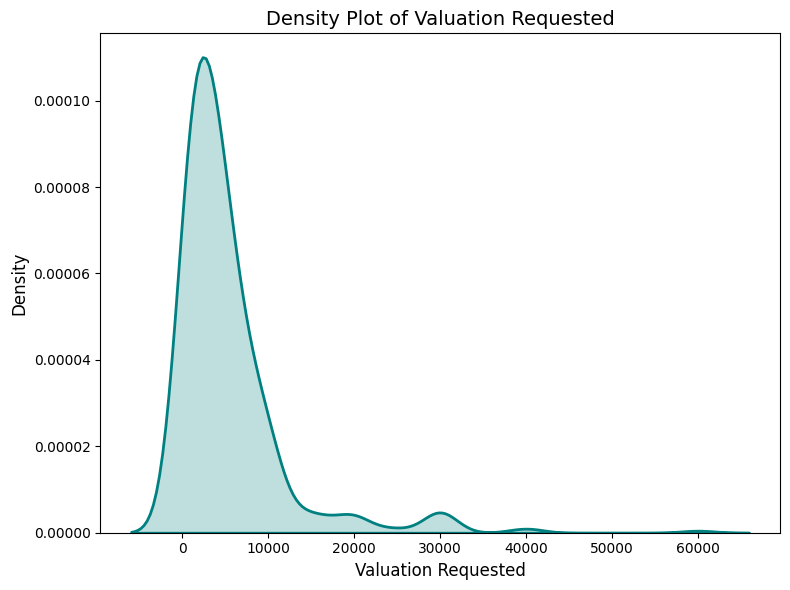

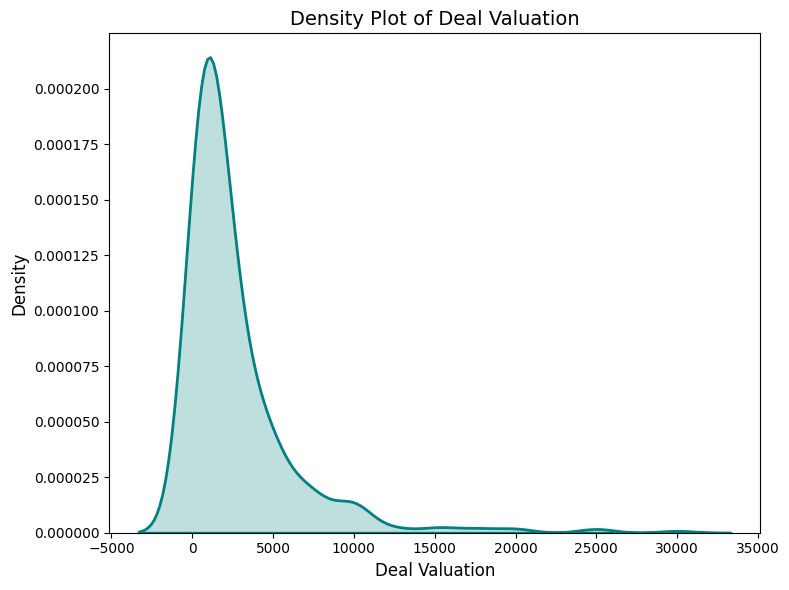

In [4]:

numeric_features = [ 'Company Age', 'Yearly Revenue',
       'Monthly Sales', 'Gross Margin', 'Net Margin', 'EBITDA', 'SKUs',
        'Original Ask Amount', 'Original Offered Equity', 'Valuation Requested' ,
        'Deal Valuation'
       ]


# Loop through every numeric feature and create a standalone Density Plot
for feature in numeric_features:
    plt.figure(figsize=(8, 6)) 
    
    # Create the Density (KDE) plot
    sns.kdeplot(
        data=df, 
        x=feature, 
        fill=True, 
        color='teal', 
        linewidth=2
    )
    
    # Dynamically update the titles and labels
    plt.title(f'Density Plot of {feature}', fontsize=14)
    plt.xlabel(f'{feature}', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.tight_layout()
    plt.show()

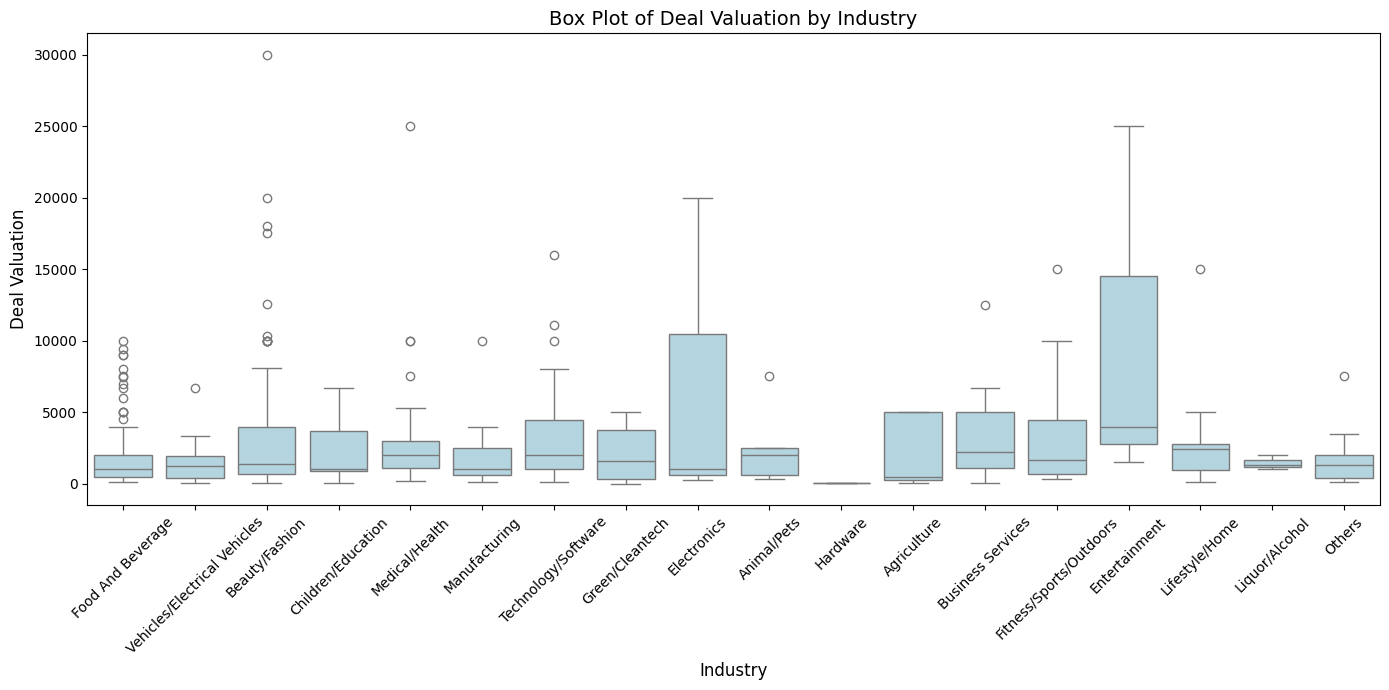

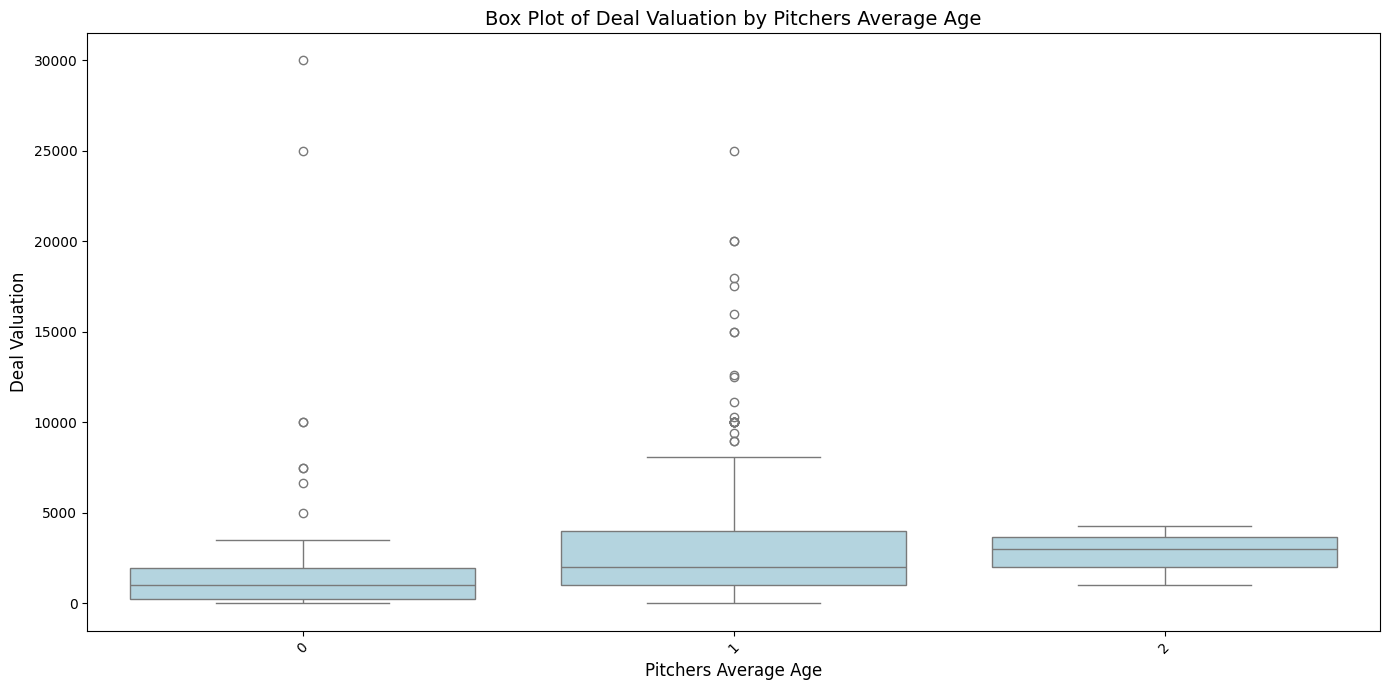

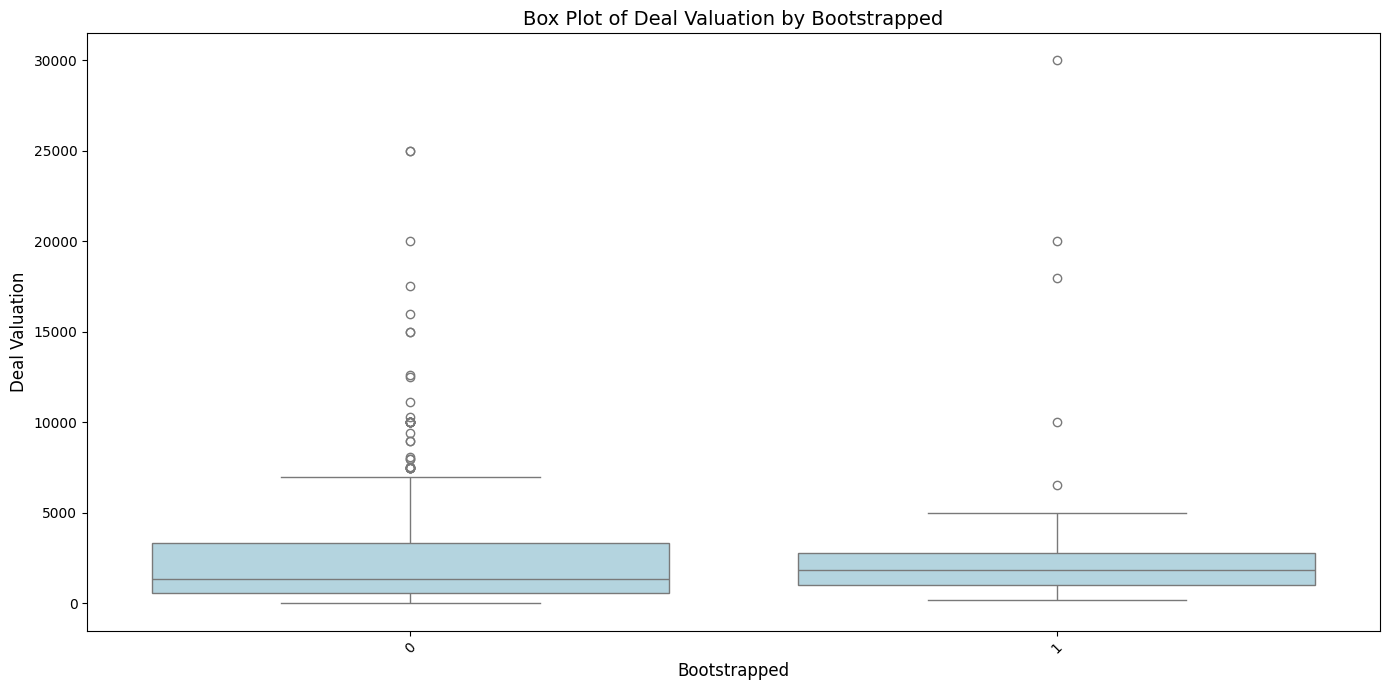

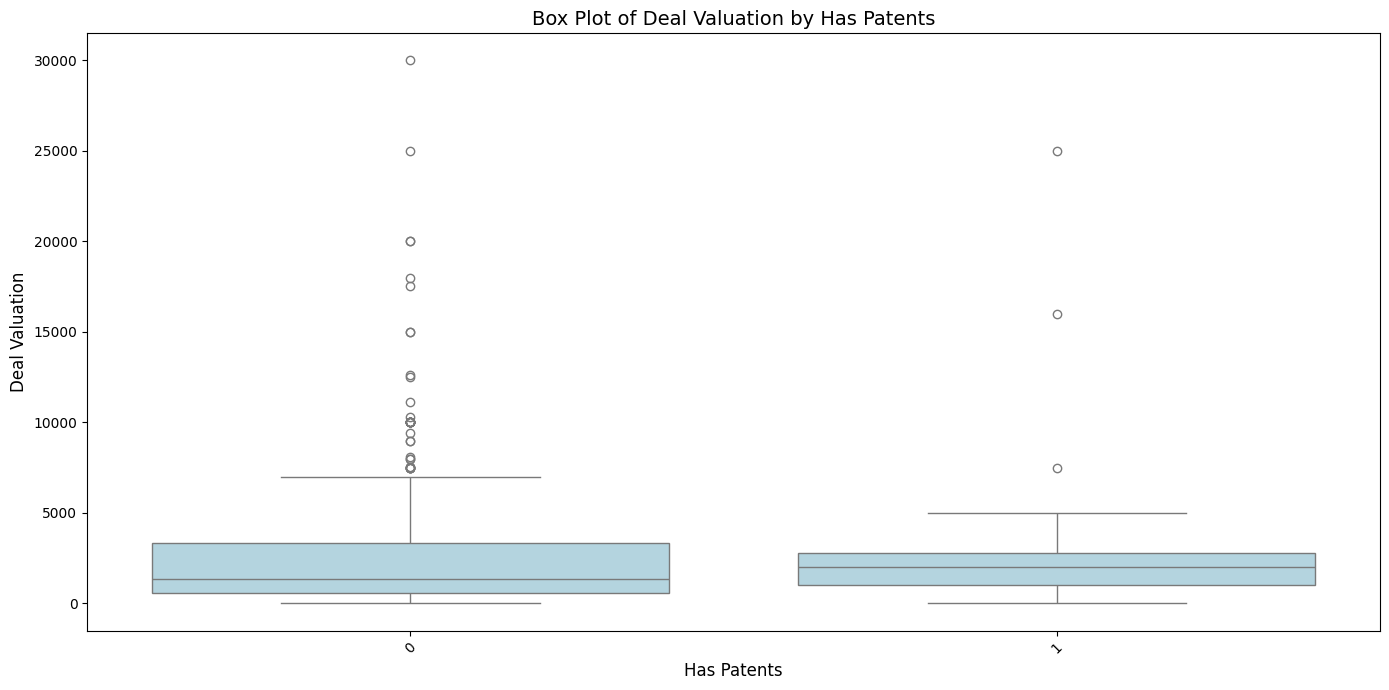

In [5]:
box_features = ['Industry', 'Pitchers Average Age' ,'Bootstrapped', 'Has Patents']

for feature in box_features:
    plt.figure(figsize=(14, 7)) 
    sns.boxplot(
        data=df, 
        x=feature, 
        y=target, 
        color='lightblue'
    )
    
    plt.title(f'Box Plot of {target} by {feature}', fontsize=14)
    plt.xlabel(f'{feature}', fontsize=12)
    plt.ylabel(f'{target}', fontsize=12)
    
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()

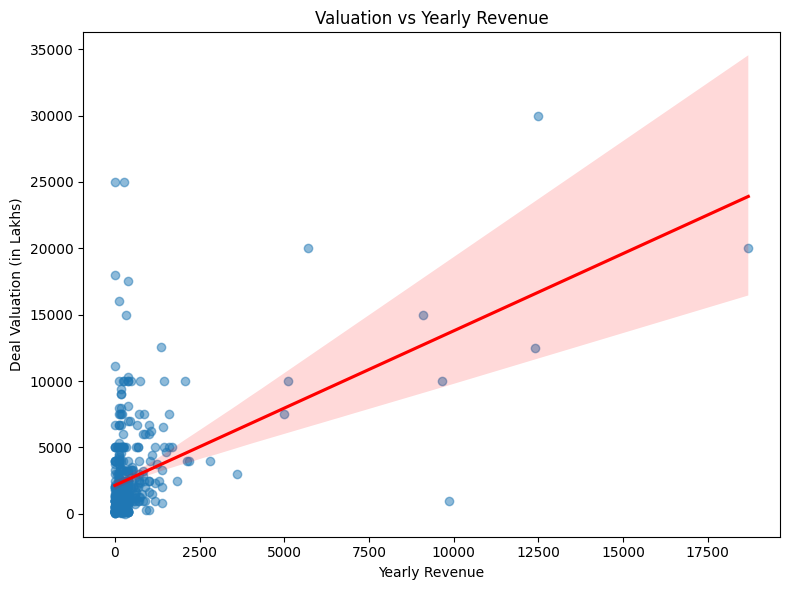

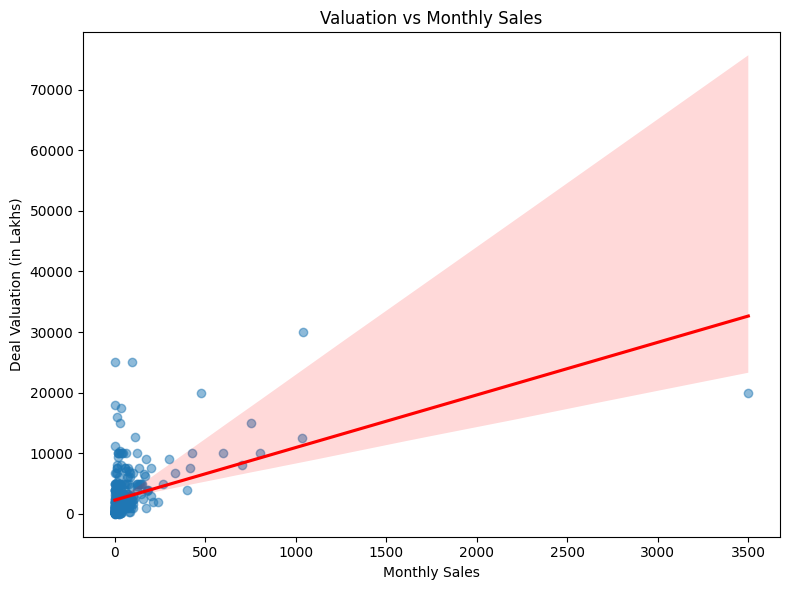

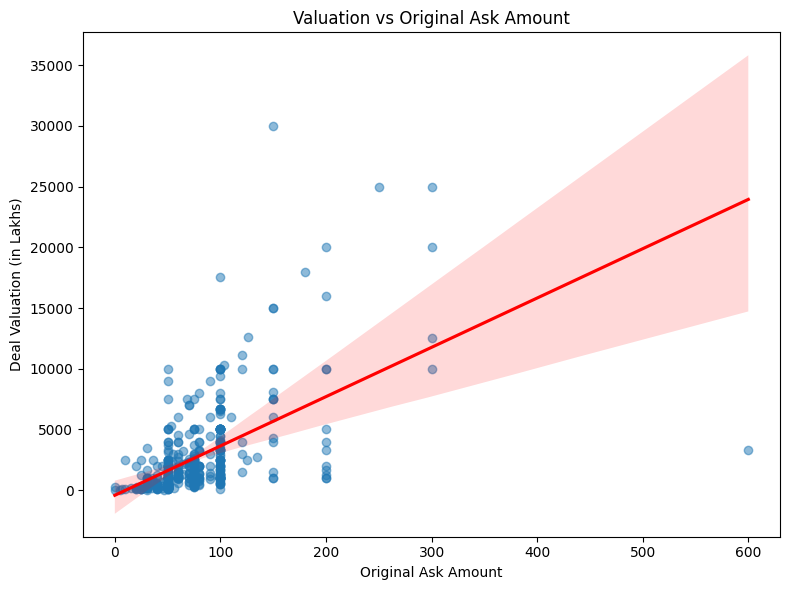

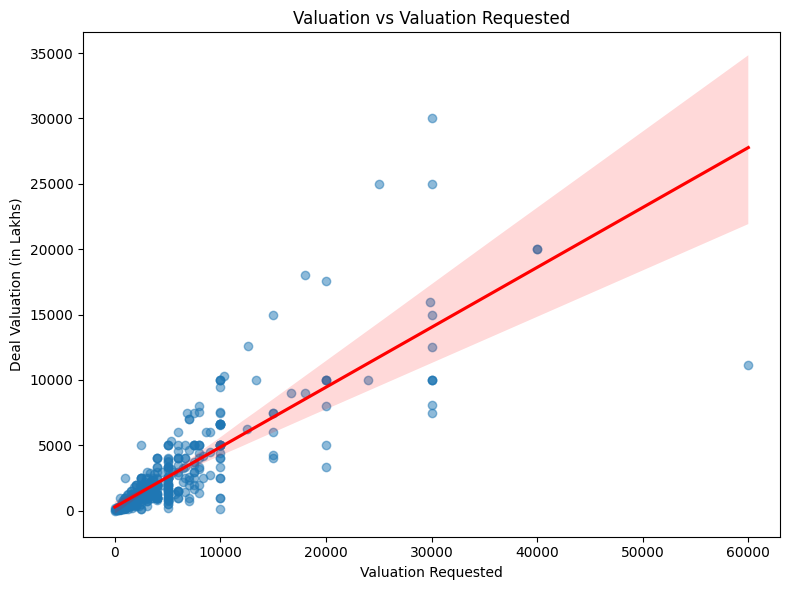

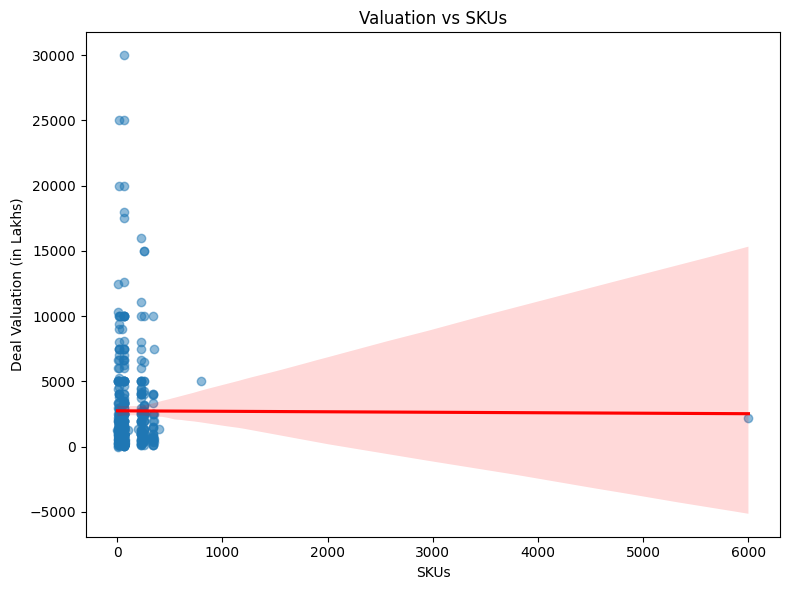

In [6]:
features = [ 'Yearly Revenue',
 'Monthly Sales',
 'Original Ask Amount',
 'Valuation Requested',
 'SKUs']

for feature in features:
    plt.figure(figsize=(8, 6)) 
    
    # Create the regression plot
    sns.regplot(
        data=df, 
        x=feature, 
        y=target, 
        scatter_kws={'alpha': 0.5}, 
        line_kws={'color': 'red'}
    )
    
    # Dynamically update the titles and labels
    plt.title(f'Valuation vs {feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Deal Valuation (in Lakhs)')
    
    plt.tight_layout()
    plt.show()

# Remove extreme outlier

In [7]:

# We use logical thresholds to remove the 'Unicorns' and data entry extremes
df = df[
    (df['Yearly Revenue'] < 10000) & 
    (df['Valuation Requested'] < 40000) &   
    (df['Monthly Sales'] < 1000) &         
    (df['SKUs'] < 2000) &                  
    (df['Original Ask Amount'] < 500)       
].copy()

display(df.shape)

(423, 15)

# Apply Log Transformation 
 1. Deal Valuations 
 2. Yearly Revenue
 3. Monthly Sale
 4. Orignal Ask Amount
 5. Valuation Request
 6. sku

 ### to  remove skewness

In [8]:
log_features = ["Deal Valuation", 'Yearly Revenue' , 'Monthly Sales' ,
                 'Original Ask Amount', 'Valuation Requested' , 'SKUs']

for col in log_features:
    df[col] = np.log1p(df[col])



display(df.head())
display(df.columns)

# for EBITDA we cand directly apply because it has negative values
# for Original Offered Equity, Gross Margin, Net Margin, Debt Interest , we can not applu log transformation as the are standardized 0 to 100

,Industry,Pitchers Average Age,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,EBITDA,Has Patents,Bootstrapped,SKUs,Original Ask Amount,Original Offered Equity,Valuation Requested,Deal Valuation,Company Age
0,Food And Beverage,1,4.564348,2.197225,51.0,20.0,6.0,0,0,3.044522,3.931826,5.0,6.908755,6.152733,5
1,Vehicles/Electrical Vehicles,0,1.609438,0.336472,95.0,20.0,15.5,0,0,4.189655,3.713572,15.0,5.590987,4.394449,4
2,Beauty/Fashion,0,0.000000,0.000000,60.0,16.0,13.5,0,0,4.189655,3.258097,10.0,5.525453,4.430817,0
3,Food And Beverage,1,6.552508,4.083171,48.0,20.0,6.0,0,0,3.044522,4.262680,1.0,8.853808,7.842279,2
7,Beauty/Fashion,0,4.615121,2.233592,60.0,16.0,13.5,0,0,1.098612,4.330733,4.0,7.536897,7.131699,2


Index(['Industry', 'Pitchers Average Age', 'Yearly Revenue', 'Monthly Sales',
       'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents', 'Bootstrapped',
       'SKUs', 'Original Ask Amount', 'Original Offered Equity',
       'Valuation Requested', 'Deal Valuation', 'Company Age'],
      dtype='object')

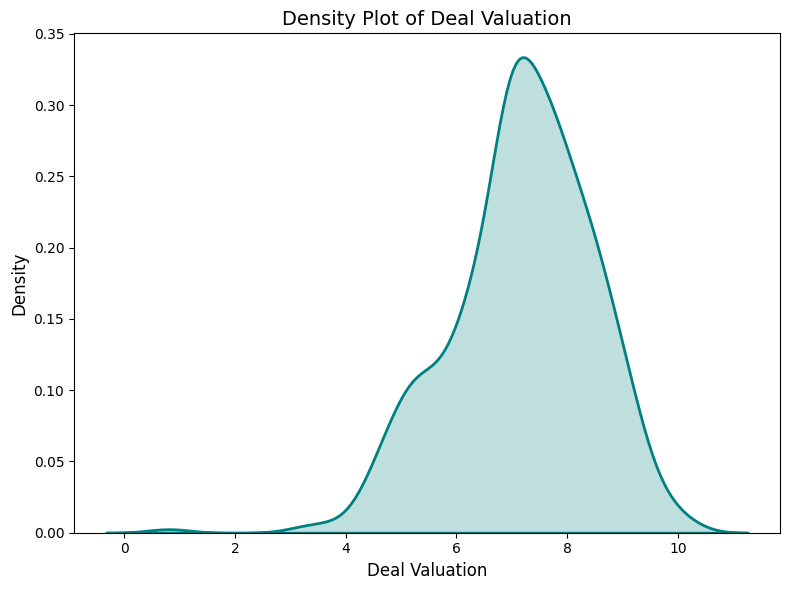

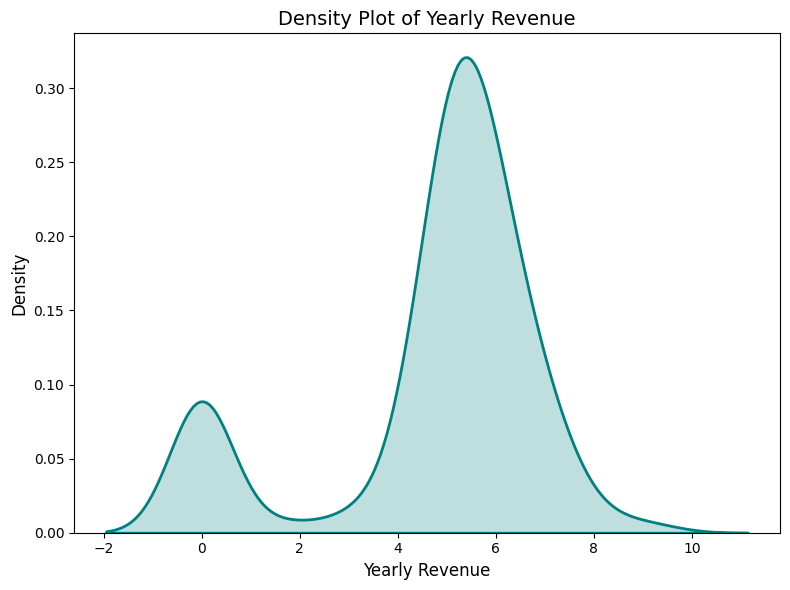

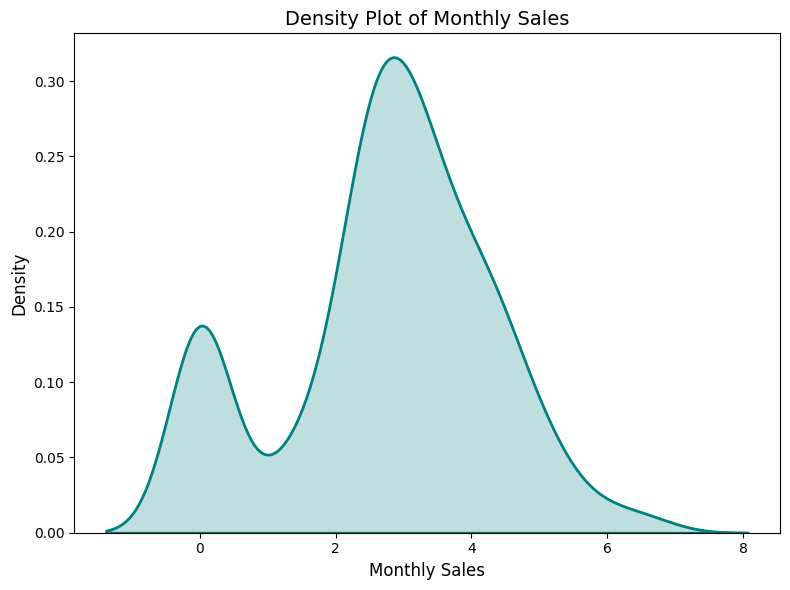

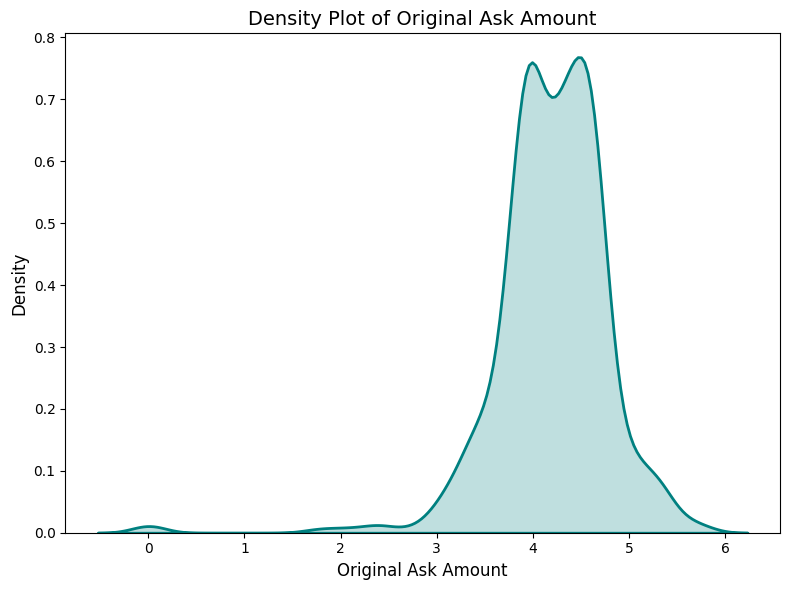

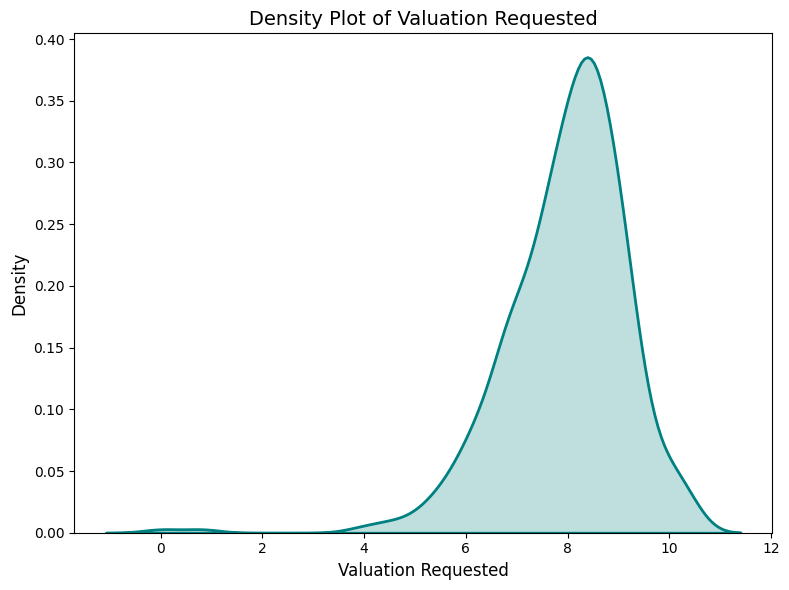

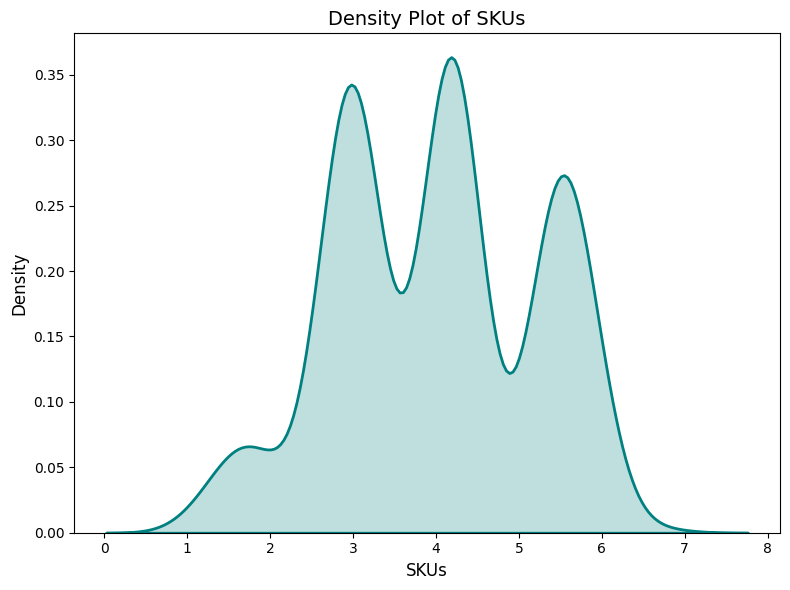

In [9]:

# Loop through every numeric feature and create a standalone Density Plot
for feature in log_features:
    plt.figure(figsize=(8, 6)) 
    
    # Create the Density (KDE) plot
    sns.kdeplot(
        data=df, 
        x=feature, 
        fill=True, 
        color='teal', 
        linewidth=2
    )
    
    # Dynamically update the titles and labels
    plt.title(f'Density Plot of {feature}', fontsize=14)
    plt.xlabel(f'{feature}', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.tight_layout()
    plt.show()

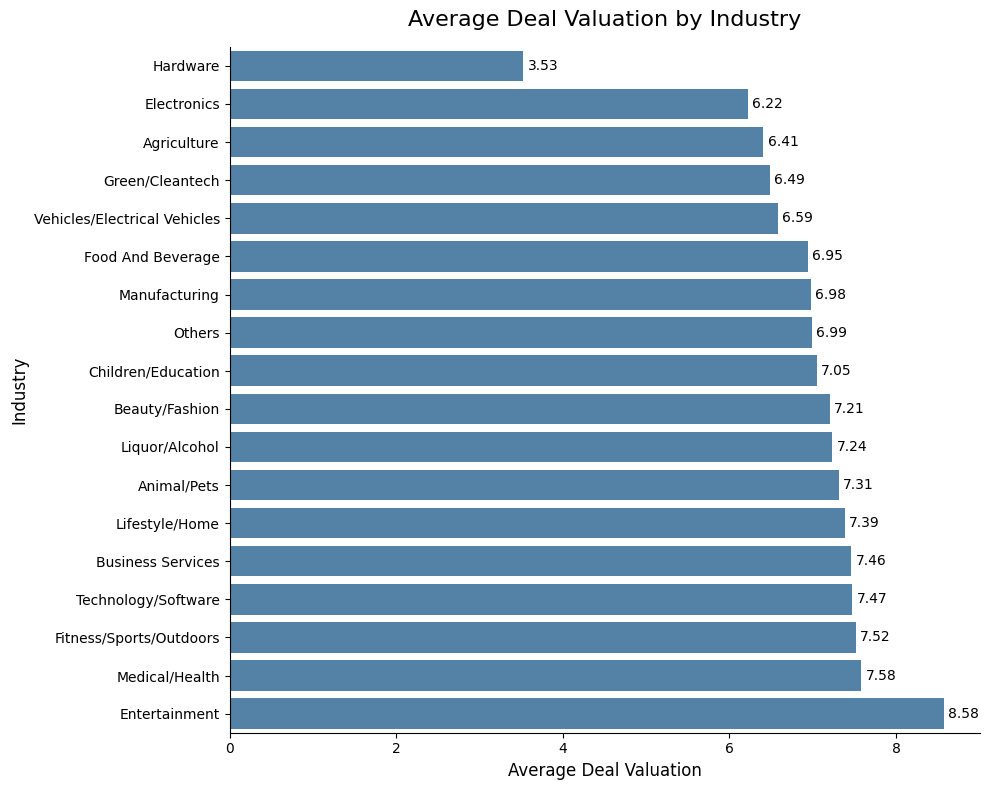

In [10]:
# 1. Group the data and calculate the average (mean) Deal Valuation by Industry
# Note: You can change .mean() to .median() if you prefer
industry_val = df.groupby('Industry')['Deal Valuation'].mean().reset_index()

# 2. Sort the values so the longest bars are at the top (ascending=True for horizontal charts)
industry_val = industry_val.sort_values('Deal Valuation', ascending=True)

# 3. Set up the plotting environment
plt.figure(figsize=(10, 8)) # Make it tall enough to fit all industry names

# 4. Create the horizontal bar chart
# We use a single color to keep it looking professional for a presentation
ax = sns.barplot(
    x='Deal Valuation', 
    y='Industry', 
    data=industry_val, 
    color='steelblue'
)

# 5. Add formatting and labels
plt.title('Average Deal Valuation by Industry', fontsize=16, pad=15)
plt.xlabel('Average Deal Valuation', fontsize=12)
plt.ylabel('Industry', fontsize=12)

# Optional: Add the exact numbers at the end of each bar for extra clarity
for index, value in enumerate(industry_val['Deal Valuation']):
    # value + 0.05 adds a tiny bit of padding between the bar and the text
    plt.text(value + 0.05, index, f'{value:.2f}', va='center', fontsize=10)

# Remove the top and right spines for a cleaner "data-ink" ratio
sns.despine()

# Adjust layout to ensure no industry names get cut off
plt.tight_layout()

# Display the chart
plt.show()

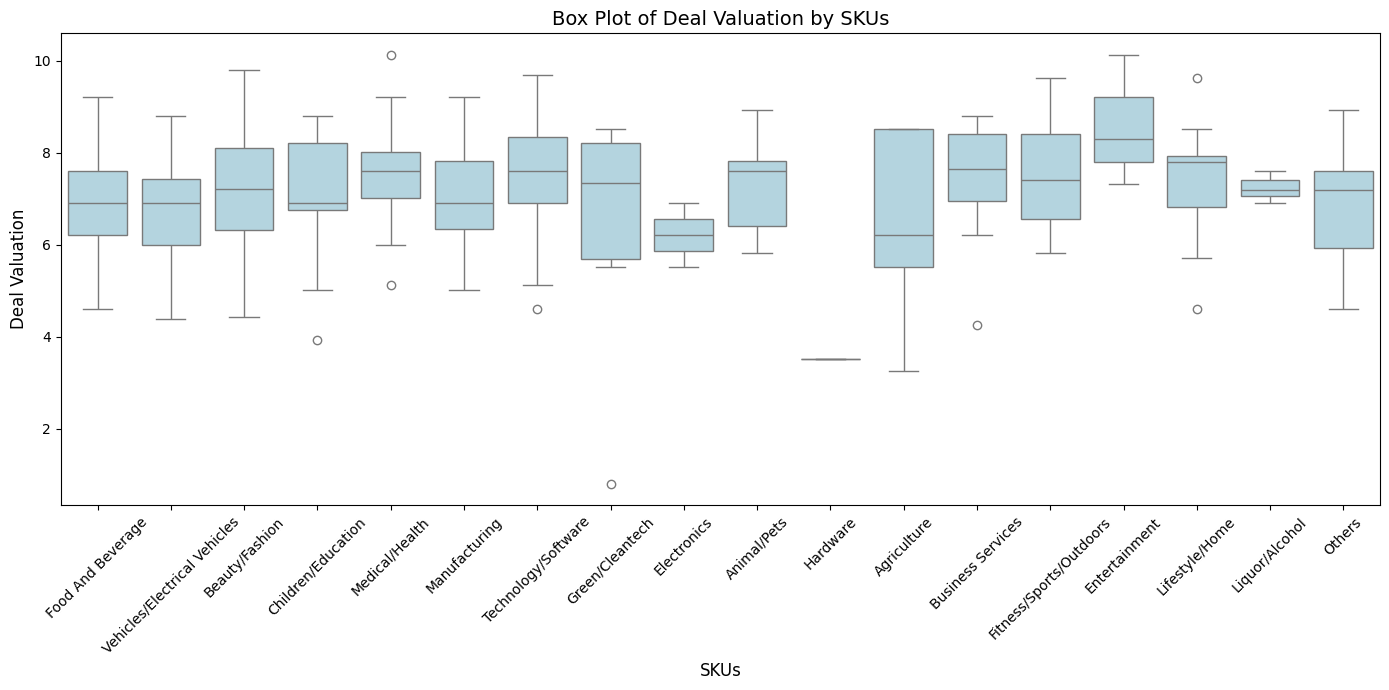

In [11]:

plt.figure(figsize=(14, 7)) 
sns.boxplot(
    data=df, 
    x='Industry', 
    y=target, 
    color='lightblue'
)
    
plt.title(f'Box Plot of {target} by {feature}', fontsize=14)
plt.xlabel(f'{feature}', fontsize=12)
plt.ylabel(f'{target}', fontsize=12)
    
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

# Linear Relationship 

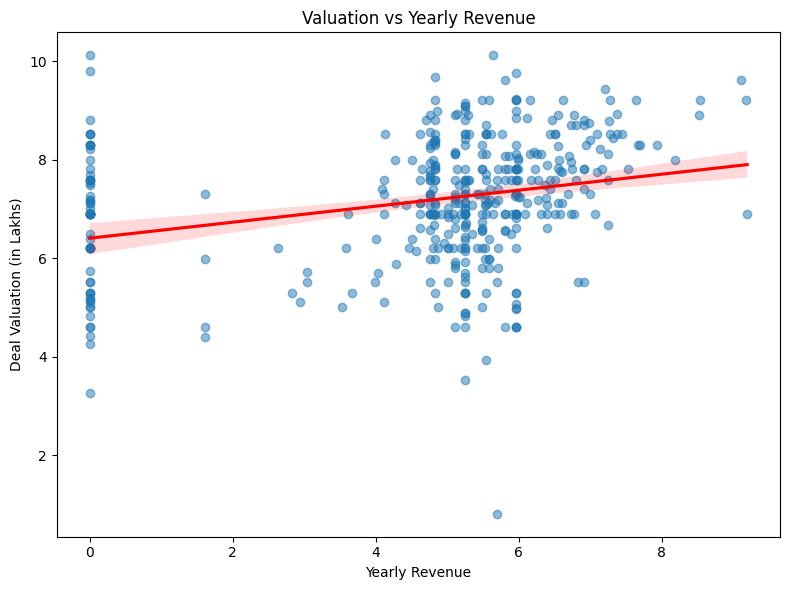

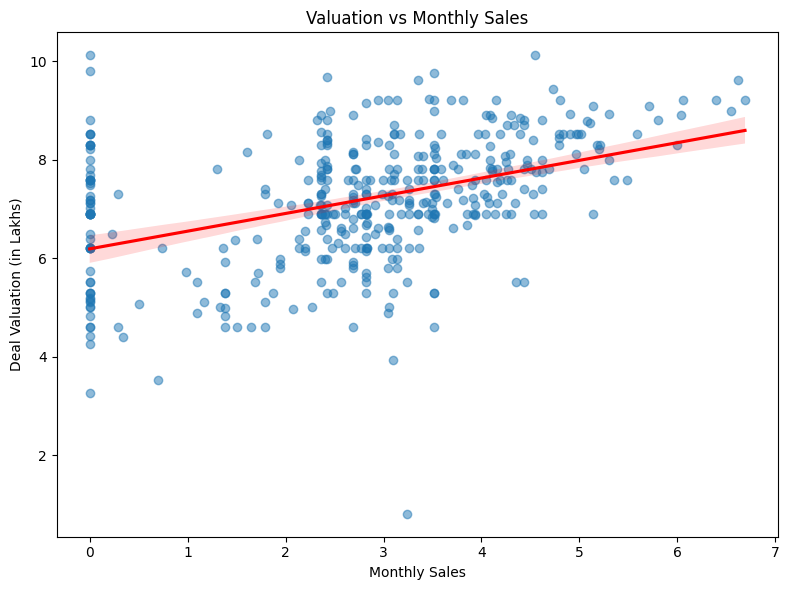

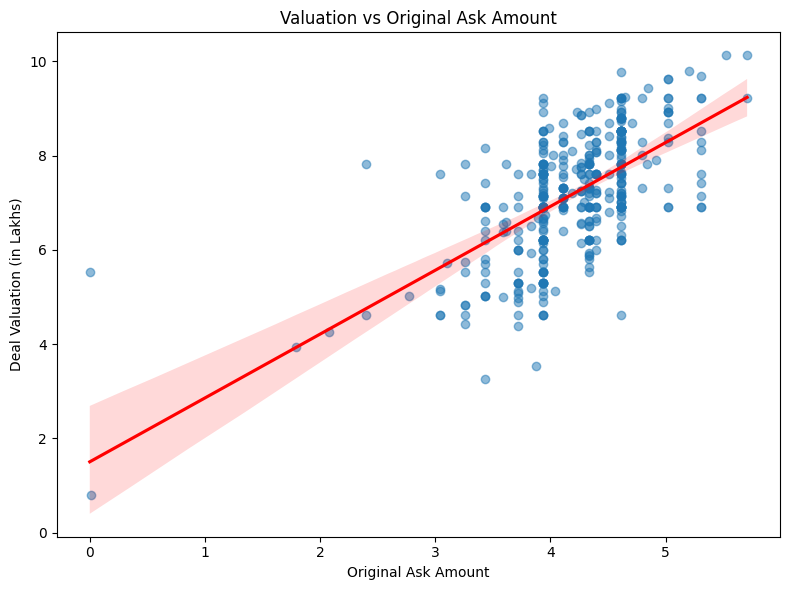

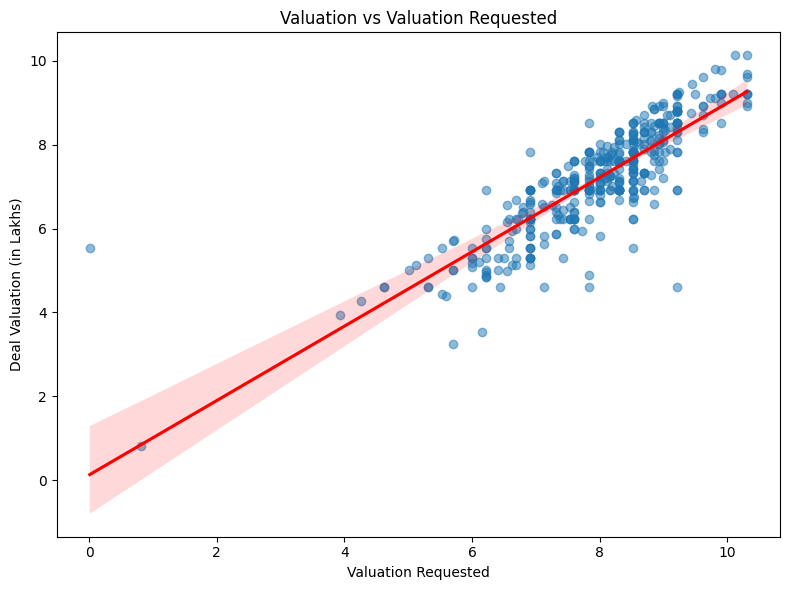

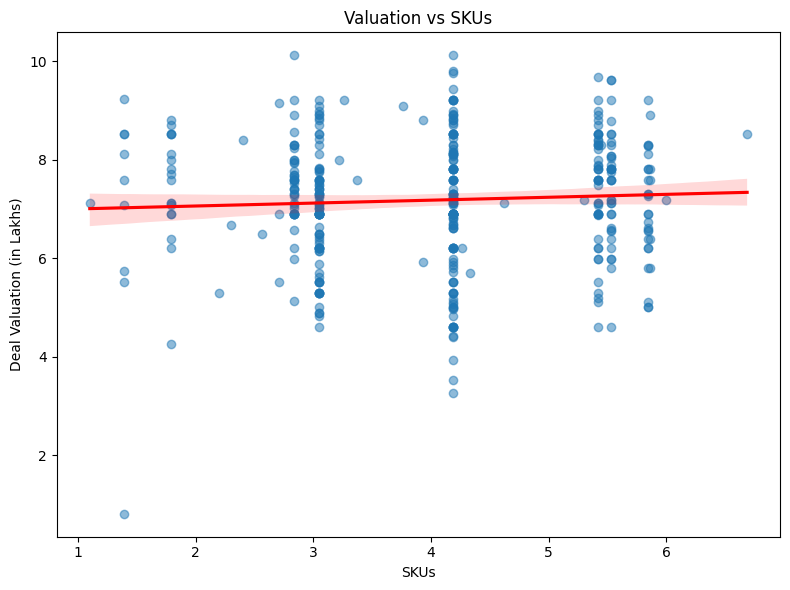

In [12]:
features = [ 'Yearly Revenue',
 'Monthly Sales',
 'Original Ask Amount',
 'Valuation Requested',
 'SKUs']

for feature in features:
    plt.figure(figsize=(8, 6)) 
    
    # Create the regression plot
    sns.regplot(
        data=df, 
        x=feature, 
        y=target, 
        scatter_kws={'alpha': 0.5}, 
        line_kws={'color': 'red'}
    )
    
    # Dynamically update the titles and labels
    plt.title(f'Valuation vs {feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Deal Valuation (in Lakhs)')
    
    plt.tight_layout()
    plt.show()

# No Multicolinearity

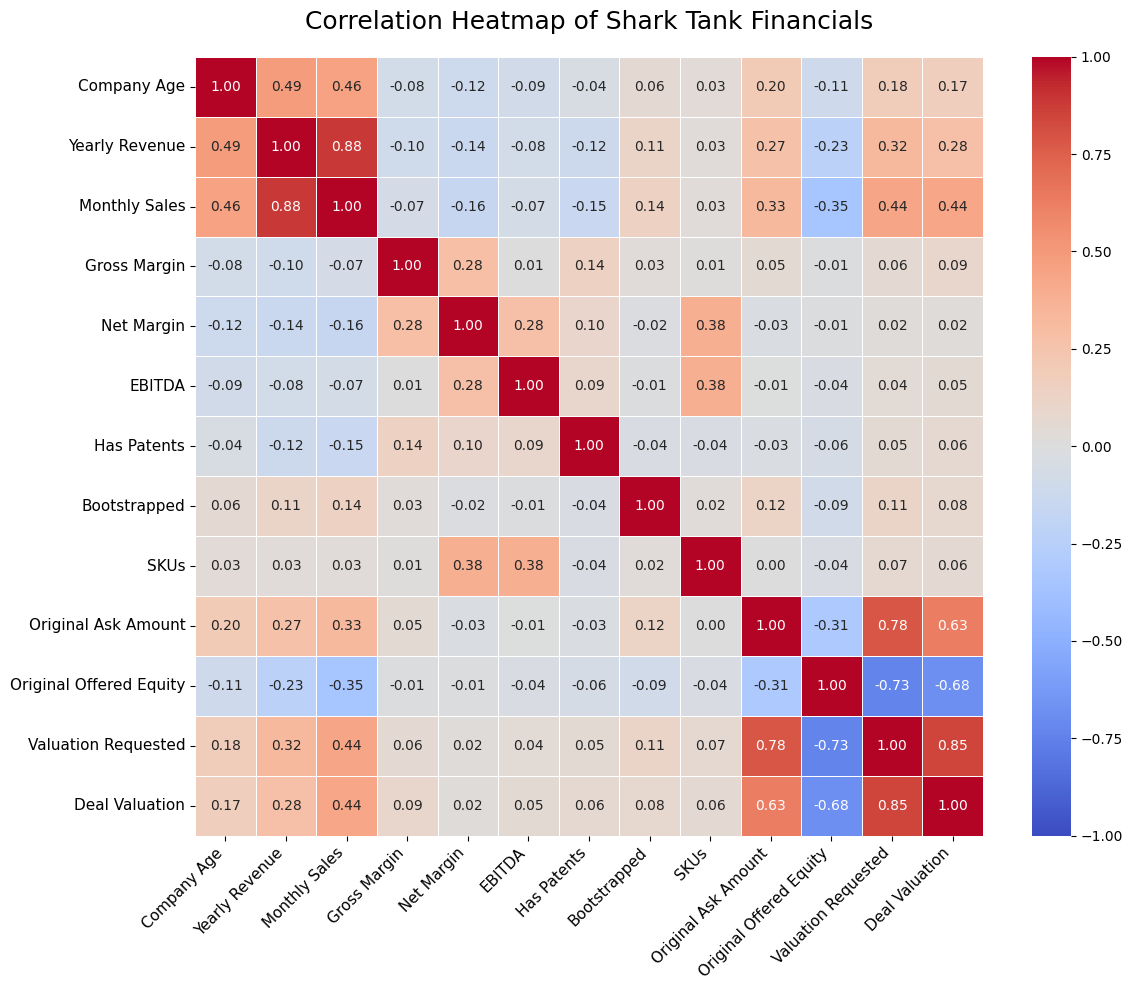

In [13]:
corr_coll = ['Company Age', 'Yearly Revenue', 'Monthly Sales', 'Gross Margin', 
             'Net Margin' , 'EBITDA', 'Has Patents', 'Bootstrapped', 'SKUs', 
             'Original Ask Amount', 'Original Offered Equity', 'Valuation Requested', 
             'Deal Valuation']

# Calculate the correlation matrix
corr_matrix = df[corr_coll].corr()

# 4. Plot the Heatmap
plt.figure(figsize=(12, 10)) # Set a large canvas size

# Use seaborn to create the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Prints the exact numbers inside the boxes
    cmap='coolwarm',     # Color scheme: Blue (-1) to Red (+1)
    fmt=".2f",           # Round numbers to 2 decimal places
    linewidths=0.5,      # Adds grid lines between boxes
    vmin=-1, vmax=1      # Locks the color scale from -1 to 1
)

# Add titles and format axes
plt.title('Correlation Heatmap of Shark Tank Financials', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Ensure everything fits perfectly
plt.tight_layout()
plt.show()

In [14]:
# need to add constant for VIF calculation
X_vif = sm.add_constant(df[corr_coll])

# Create a dataframe to store the results
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

# Calculate VIF for each feature
vif_data["VIF Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF Score", ascending=False))
display( "mean VIF Score: ", vif_data[vif_data["Feature"] != "const"]["VIF Score"].mean() )


,Feature,VIF Score
12,Valuation Requested,11.062106
3,Monthly Sales,5.866424
2,Yearly Revenue,5.176508
10,Original Ask Amount,4.513801
13,Deal Valuation,3.973365
11,Original Offered Equity,3.680994
5,Net Margin,1.382666
9,SKUs,1.355002
1,Company Age,1.351911
6,EBITDA,1.232890


'mean VIF Score: '

3.2981979063003917

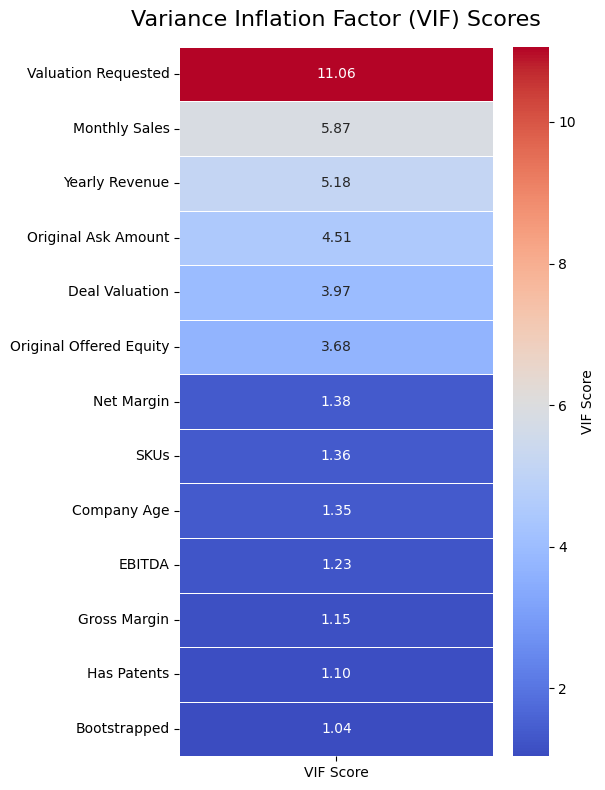

In [15]:
# 1. Prepare the data: Remove the 'const' row and sort by VIF Score descending
vif_plot_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF Score", ascending=False)

# 2. Set the 'Feature' column as the index so seaborn knows what to label the rows
vif_plot_data = vif_plot_data.set_index("Feature")

# 3. Set up the plotting environment
plt.figure(figsize=(6, 8)) # Make it tall enough to fit all feature names

# 4. Create the Heatmap
# 'coolwarm' places high concern variables (VIF > 5) in red, and safe ones in blue
sns.heatmap(
    vif_plot_data, 
    annot=True,          # Shows the exact number in the box
    cmap='coolwarm',     # Color gradient
    fmt=".2f",           # Rounds to 2 decimal places
    linewidths=.5,       # Adds a small border between boxes
    cbar_kws={'label': 'VIF Score'}
)

# 5. Formatting
plt.title('Variance Inflation Factor (VIF) Scores', fontsize=16, pad=15)
plt.ylabel('') # Hides the 'Feature' axis label for a cleaner look
plt.tight_layout()

# 6. Display the plot
plt.show()

# columns to drop 
1. Monthly Sales 
2. Valuation Requested

In [16]:
df = df.drop(columns=['Monthly Sales', 'Valuation Requested'  ])

display(df.head())
display(df.shape)

,Industry,Pitchers Average Age,Yearly Revenue,Gross Margin,Net Margin,EBITDA,Has Patents,Bootstrapped,SKUs,Original Ask Amount,Original Offered Equity,Deal Valuation,Company Age
0,Food And Beverage,1,4.564348,51.0,20.0,6.0,0,0,3.044522,3.931826,5.0,6.152733,5
1,Vehicles/Electrical Vehicles,0,1.609438,95.0,20.0,15.5,0,0,4.189655,3.713572,15.0,4.394449,4
2,Beauty/Fashion,0,0.000000,60.0,16.0,13.5,0,0,4.189655,3.258097,10.0,4.430817,0
3,Food And Beverage,1,6.552508,48.0,20.0,6.0,0,0,3.044522,4.262680,1.0,7.842279,2
7,Beauty/Fashion,0,4.615121,60.0,16.0,13.5,0,0,1.098612,4.330733,4.0,7.131699,2


(423, 13)

In [17]:
display(df.isnull().sum())
display(df.shape)

Industry                   0
Pitchers Average Age       0
Yearly Revenue             0
Gross Margin               0
Net Margin                 0
EBITDA                     0
Has Patents                0
Bootstrapped               0
SKUs                       0
Original Ask Amount        0
Original Offered Equity    0
Deal Valuation             0
Company Age                0
dtype: int64

(423, 13)

# one-hot encoding 

### for industry column

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# The drop='first' parameter automatically handles the Dummy Variable Trap
transformer = ColumnTransformer(
    transformers=[
        ('cat_encoder', OneHotEncoder(drop=None, sparse_output=False), ['Industry'])
    ],
    remainder='passthrough' 
)

transformer.set_output(transform="pandas")
df_encoded = transformer.fit_transform(df)

display(df_encoded.head())


,cat_encoder__Industry_Agriculture,cat_encoder__Industry_Animal/Pets,cat_encoder__Industry_Beauty/Fashion,cat_encoder__Industry_Business Services,cat_encoder__Industry_Children/Education,cat_encoder__Industry_Electronics,cat_encoder__Industry_Entertainment,cat_encoder__Industry_Fitness/Sports/Outdoors,cat_encoder__Industry_Food And Beverage,cat_encoder__Industry_Green/Cleantech,...,remainder__Gross Margin,remainder__Net Margin,remainder__EBITDA,remainder__Has Patents,remainder__Bootstrapped,remainder__SKUs,remainder__Original Ask Amount,remainder__Original Offered Equity,remainder__Deal Valuation,remainder__Company Age
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,51.0,20.0,6.0,0,0,3.044522,3.931826,5.0,6.152733,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,95.0,20.0,15.5,0,0,4.189655,3.713572,15.0,4.394449,4
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,16.0,13.5,0,0,4.189655,3.258097,10.0,4.430817,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,48.0,20.0,6.0,0,0,3.044522,4.262680,1.0,7.842279,2
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,16.0,13.5,0,0,1.098612,4.330733,4.0,7.131699,2


In [19]:
df_encoded.columns

Index(['cat_encoder__Industry_Agriculture',
       'cat_encoder__Industry_Animal/Pets',
       'cat_encoder__Industry_Beauty/Fashion',
       'cat_encoder__Industry_Business Services',
       'cat_encoder__Industry_Children/Education',
       'cat_encoder__Industry_Electronics',
       'cat_encoder__Industry_Entertainment',
       'cat_encoder__Industry_Fitness/Sports/Outdoors',
       'cat_encoder__Industry_Food And Beverage',
       'cat_encoder__Industry_Green/Cleantech',
       'cat_encoder__Industry_Hardware',
       'cat_encoder__Industry_Lifestyle/Home',
       'cat_encoder__Industry_Liquor/Alcohol',
       'cat_encoder__Industry_Manufacturing',
       'cat_encoder__Industry_Medical/Health', 'cat_encoder__Industry_Others',
       'cat_encoder__Industry_Technology/Software',
       'cat_encoder__Industry_Vehicles/Electrical Vehicles',
       'remainder__Pitchers Average Age', 'remainder__Yearly Revenue',
       'remainder__Gross Margin', 'remainder__Net Margin', 'remainder__EBITD

In [20]:
df_encoded.columns = ['Agriculture',
       'Animal/Pets',
       'Beauty/Fashion',
       'Business Services',
       'Children/Education',
       'Electronics',
       'Entertainment',
       'Fitness/Sports/Outdoors',
       'Food And Beverage',
       'Green/Cleantech',
       'Hardware',
       'Lifestyle/Home',
       'Liquor/Alcohol',
       'Manufacturing',
       'Medical/Health', 'Others',
       'Technology/Software',
       'Vehicles/Electrical Vehicles',
       'Pitchers Average Age', 'Yearly Revenue',
       'Gross Margin', 'Net Margin', 'EBITDA',
       'Has Patents', 'Bootstrapped', 'SKUs',
       'Original Ask Amount', 'Original Offered Equity',
       'Deal Valuation', 'Company Age']

# Standardization 


In [21]:
from sklearn.preprocessing import StandardScaler

# Define only the continuous columns

continuous_cols = ['Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA',
                    'SKUs','Original Ask Amount', 'Original Offered Equity',
                     'Company Age']

# Apply StandardScaler
scaler = StandardScaler()
df_encoded[continuous_cols] = scaler.fit_transform(df_encoded[continuous_cols])

In [22]:
df_encoded.to_csv('data/MLR_Friendly_Shark_Tank_India.csv', index=False)